In [27]:
with open("GO_Biological_Process_2025") as f:
    lines = f.readlines()

go_terms_to_check = {
    line.split("\t\t")[0]: line.split("\t\t")[1].rstrip("\n").split("\t")
    for line in lines
}

In [ ]:
import numpy as np
import pandas as pd

table = pd.read_csv("DE_results.csv", index_col = 0)
table["weights"] = table["baseMean"] / table["baseMean"].sum()
table["scaled_statistic"] = table["weights"] * table["stat"]

In [ ]:
from tqdm import tqdm

output = {}

for term in tqdm(go_terms_to_check):
    genes = go_terms_to_check[term]
    table[table.symbol.isin(genes)]

    weighted_precision = table[table.symbol.isin(genes)]["weights"] / table[table.symbol.isin(genes)]["lfcSE"].pow(2)
    beta = (weighted_precision * table[table.symbol.isin(genes)]["log2FoldChange"]).sum() / weighted_precision.sum()
    variance = np.sqrt((weighted_precision / weighted_precision.sum()).pow(2).sum())

    output[term] = {
        "stat": table[table.symbol.isin(genes)]["scaled_statistic"].sum(),
        "n_terms": len(genes),
        "stouffer": table[table.symbol.isin(genes)]["scaled_statistic"].sum() / np.sqrt(table[table.symbol.isin(genes)]["weights"].pow(2).sum()),
        "weight": table[table.symbol.isin(genes)]["weights"].sum(),
        "beta": beta,
        "variance": variance
    }


  0%|          | 0/5343 [00:00<?, ?it/s]/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_88324/4097051265.py:9: RuntimeWarning: invalid value encountered in scalar divide
  beta = (weighted_precision * table[table.symbol.isin(genes)]["log2FoldChange"]).sum() / weighted_precision.sum()
/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_88324/4097051265.py:15: RuntimeWarning: invalid value encountered in scalar divide
  "stouffer": table[table.symbol.isin(genes)]["scaled_statistic"].sum() / np.sqrt(table[table.symbol.isin(genes)]["weights"].pow(2).sum()),
100%|██████████| 5343/5343 [00:20<00:00, 260.88it/s]


In [255]:
result_table = pd.DataFrame(output).T
result_table["zval"] = (result_table["beta"] * np.sqrt(result_table["n_terms"])) / np.sqrt(result_table["variance"])
result_table["pval"] = 2 * (1 - norm.cdf(np.abs(result_table["zval"])))
result_table["padj"] = result_table["pval"] * 5343

result_table["log10p"] = -np.log10(result_table["padj"])

/Users/jameshaberberger/GitHub/meta-estimators/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='beta', ylabel='log10p'>

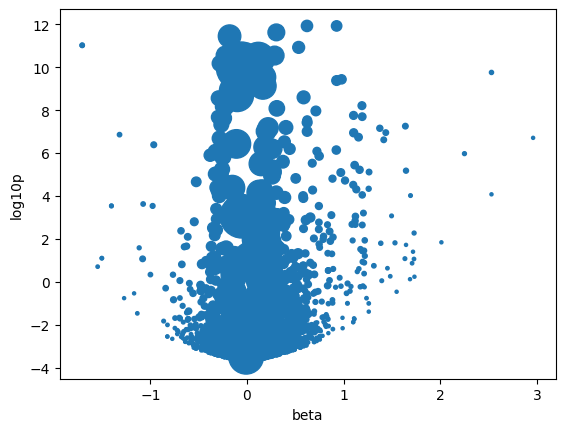

In [267]:
from scipy.stats import norm

result_table.plot.scatter(x="beta", y="log10p", s="n_terms")

In [292]:
result_table.query("padj < 0.05 and abs(beta) > 1 and weight > 0.01").sort_values(by="beta")

,stat,n_terms,stouffer,weight,beta,variance,zval,pval,padj,log10p
Defense Response to Gram-negative Bacterium (GO:0050829),0.062431,87.0,7.568846,0.011178,1.036740,0.847376,10.504887,0.000000e+00,0.000000e+00,inf
Positive Regulation of Interleukin-8 Production (GO:0032757),0.060372,63.0,7.381427,0.010670,1.046200,0.864358,8.931781,0.000000e+00,0.000000e+00,inf
Negative Regulation of Extrinsic Apoptotic Signaling Pathway via Death Domain Receptors (GO:1902042),0.065142,24.0,7.963372,0.010519,1.099125,0.853789,5.827433,5.628658e-09,3.007392e-05,4.521810
Regulation of Extrinsic Apoptotic Signaling Pathway via Death Domain Receptors (GO:1902041),0.077230,32.0,8.750921,0.014508,1.102362,0.801556,6.965177,3.279821e-12,1.752408e-08,7.756365
Regulation of Cell Adhesion Mediated by Integrin (GO:0033628),0.061462,33.0,7.470411,0.010892,1.103771,0.896127,6.698093,2.111578e-11,1.128216e-07,6.947608
Regulation of Monocyte Chemotaxis (GO:0090025),0.060877,28.0,7.416504,0.010072,1.113614,0.911893,6.170804,6.794352e-10,3.630222e-06,5.440067
Regulation of Smooth Muscle Cell Migration (GO:0014910),0.064906,19.0,7.802766,0.011859,1.118493,0.897404,5.146546,2.653270e-07,1.417642e-03,2.848433
Regulation of Plasminogen Activation (GO:0010755),0.091423,16.0,8.948767,0.020779,1.120337,0.781101,5.070553,3.966620e-07,2.119365e-03,2.673794
Regulation of Endothelial Cell Apoptotic Process (GO:2000351),0.073919,47.0,8.393957,0.013910,1.129895,0.862905,8.338832,0.000000e+00,0.000000e+00,inf
Negative Regulation of Response to Wounding (GO:1903035),0.060451,24.0,7.367506,0.010035,1.130719,0.929497,5.745615,9.158741e-09,4.893515e-05,4.310379


<Axes: xlabel='log2FoldChange', ylabel='stat'>

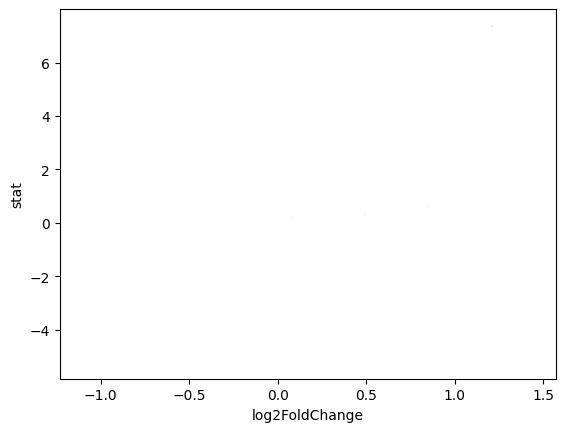

In [ ]:
genes = go_terms_to_check["Positive Regulation of Interleukin-8 Production (GO:0032757)"]
example = table[table.symbol.isin(genes)]
example["uci"] = example["log2FoldChange"] + example["lfcSE"] * 1.96
example["lci"] = example["log2FoldChange"] - example["lfcSE"] * 1.96

example.plot.scatter(x="log2FoldChange", y="stat", s="baseMean")

In [ ]:
import forestplot as fp
fp.forestplot(
    example,
    estimate="log2FoldChange",
    ll="lci",
    hl="uci",
    varlabel="symbol"
)

In [ ]:
# Mass Distribution

In [310]:
import pandas as pd

def term_feature_dict_to_binary_matrix(term_to_features):
    """
    Convert a dictionary of {term: [features]} into a binary adjacency matrix.

    Returns
    -------
    adj : pd.DataFrame
        Binary matrix with rows as features and columns as terms.
        adj.loc[feature, term] = 1 if feature is associated with term, else 0.
    """
    terms = list(term_to_features.keys())

    features = sorted({
        feature
        for feature_list in term_to_features.values()
        for feature in feature_list
    })

    adj = pd.DataFrame(0, index=features, columns=terms, dtype=int)

    for term, feature_list in term_to_features.items():
        adj.loc[feature_list, term] = 1

    return adj

In [772]:
import numpy as np
from tqdm import tqdm

def sinkhorn_binary(
    A,
    gene_weights,
    term_weights=None,
    n_iter=5000,
    eps=1e-12,
    check_every=20,
):
    A = A.astype(float)

    r = np.asarray(gene_weights, dtype=float)
    r = r / r.sum()

    if term_weights is None:
        c = np.ones(A.shape[1], dtype=float)
    else:
        c = np.asarray(term_weights, dtype=float)
    c = c / c.sum()

    u = np.ones(A.shape[0], dtype=float)
    v = np.ones(A.shape[1], dtype=float)

    prev_P = None
    pbar = tqdm(range(n_iter))

    for it in pbar:
        u = r / (A @ v + eps)
        v = c / (A.T @ u + eps)

        if it % check_every == 0 or it == n_iter - 1:
            P = (u[:, None] * A) * v[None, :]

            row_diff = P.sum(axis=1) - r
            col_diff = P.sum(axis=0) - c

            row_err = np.abs(row_diff).sum()
            col_err = np.abs(col_diff).sum()
            max_row_err = np.abs(row_diff).max()
            max_col_err = np.abs(col_diff).max()

            if prev_P is None:
                frob_pct_change = np.nan
            else:
                denom = np.linalg.norm(prev_P, ord="fro") + eps
                frob_pct_change = 100 * np.linalg.norm(P - prev_P, ord="fro") / denom

            pbar.set_postfix({
                "row_L1": f"{row_err:.2e}",
                "col_L1": f"{col_err:.2e}",
                "row_max": f"{max_row_err:.2e}",
                "col_max": f"{max_col_err:.2e}",
                "frob_%Δ": "nan" if prev_P is None else f"{frob_pct_change:.2e}",
            })

            if frob_pct_change < 1e-1:
                P = (u[:, None] * A) * v[None, :]
                return P

            prev_P = P.copy()

    P = (u[:, None] * A) * v[None, :]
    return P

In [773]:
go_term_A = term_feature_dict_to_binary_matrix(go_terms_to_check)
go_term_A = go_term_A[go_term_A.index.isin(table.symbol)]
go_term_A = go_term_A.loc[:, go_term_A.gt(0).sum(axis=0).gt(0)]

subset = table[table.symbol.isin(go_term_A.index)]

In [774]:
OT_mat = sinkhorn_binary(
    go_term_A.values, 
    subset.set_index("symbol").loc[go_term_A.index, "weights"].values, 
    term_weights=(go_term_A.gt(0).sum(axis=0).apply(np.sqrt)).values, 
    n_iter=5000, 
    eps=1e-12
)

 14%|█▎        | 680/5000 [00:33<03:34, 20.16it/s, row_L1=1.66e-01, col_L1=1.66e-01, row_max=1.18e-02, col_max=1.21e-04, frob_%Δ=7.87e-02]


In [775]:
OT_mat = pd.DataFrame(
    OT_mat,
    index=go_term_A.index,
    columns=go_term_A.columns
)

In [776]:
weighted_precision = OT_mat.div(table[table.symbol.isin(go_term_A.index)].set_index("symbol")["lfcSE"].pow(2), axis=0)
beta = (table[table.symbol.isin(go_term_A.index)].set_index("symbol")["log2FoldChange"] @ weighted_precision) / weighted_precision.sum(axis=0)
variances = np.sqrt((weighted_precision / weighted_precision.sum(axis=0)).pow(2).sum())

In [797]:
result_table = pd.DataFrame({
    "assigned_weight": OT_mat.sum(axis=0),
    "beta": beta,
    "variance": variances,
    "n_terms": (OT_mat > 0).sum(axis=0),
    "allotted_weight": table[table.symbol.isin(go_term_A.index)].set_index("symbol")["baseMean"] @ OT_mat
})

In [802]:
result_table = result_table.query("n_terms > 5")

In [803]:
result_table["zval"] = (result_table["beta"]) / np.sqrt(result_table["variance"])
result_table["pval"] = 2 * (1 - norm.cdf(np.abs(result_table["zval"])))
result_table["padj"] = result_table["pval"] * result_table.shape[0]

result_table["log10p"] = -np.log10(result_table["pval"])
result_table["log10padj"] = -np.log10(result_table["padj"])
result_table['scaled_assigned_weight'] = result_table["assigned_weight"] * 1000
result_table['upper_ci'] = result_table['beta'] + 1.96 * result_table['variance']
result_table['lower_ci'] = result_table['beta'] - 1.96 * result_table['variance']
result_table

,assigned_weight,beta,variance,n_terms,allotted_weight,zval,pval,padj,log10p,log10padj,scaled_assigned_weight,upper_ci,lower_ci
'De Novo' Post-Translational Protein Folding (GO:0051084),0.000284,0.148516,0.490264,32,0.578624,0.212109,0.832022,3052.688777,0.079865,-3.484683,0.284145,1.109433,-0.812401
2-Oxoglutarate Metabolic Process (GO:0006103),0.000143,0.028993,0.545737,10,0.187971,0.039247,0.968693,3554.136354,0.013814,-3.550734,0.143107,1.098637,-1.040651
3'-UTR-mediated mRNA Destabilization (GO:0061158),0.000159,-0.210902,0.545048,14,0.242308,-0.285669,0.775132,2843.957584,0.110625,-3.453923,0.158623,0.857391,-1.279195
3'-UTR-mediated mRNA Stabilization (GO:0070935),0.000153,-0.260202,0.638040,10,0.345118,-0.325751,0.744613,2731.983619,0.128070,-3.436478,0.153093,0.990357,-1.510760
3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),0.000151,0.396902,0.746410,9,0.768424,0.459404,0.645944,2369.968932,0.189805,-3.374743,0.150691,1.859865,-1.066061
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xenobiotic Catabolic Process (GO:0042178),0.000107,-0.331950,0.637521,10,0.068895,-0.415744,0.677598,2486.105739,0.169028,-3.395520,0.107015,0.917591,-1.581491
Xenobiotic Transport (GO:0042908),0.000134,0.554297,0.533565,10,1.214146,0.758837,0.447950,1643.527798,0.348771,-3.215777,0.134393,1.600085,-0.491491
Zinc Ion Transmembrane Transport (GO:0071577),0.000166,0.388486,0.437597,12,0.354701,0.587270,0.557022,2043.714762,0.254127,-3.310420,0.166121,1.246177,-0.469205
Zinc Ion Transport (GO:0006829),0.000194,0.239471,0.380875,16,0.368460,0.388026,0.697996,2560.949047,0.156147,-3.408401,0.193925,0.985986,-0.507045


<Axes: xlabel='beta', ylabel='log10p'>

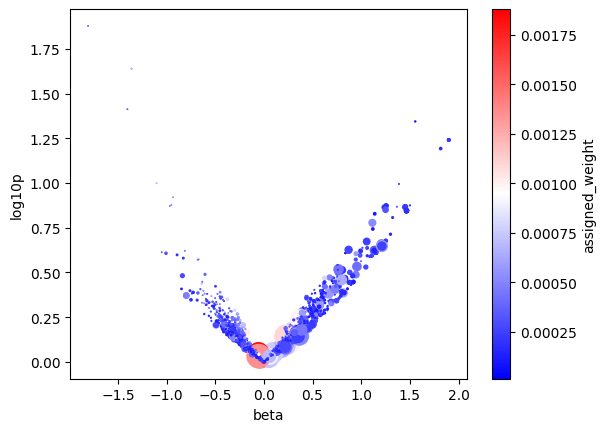

In [804]:
result_table.plot.scatter(x="beta", y="log10p", s="allotted_weight", c="assigned_weight", cmap='bwr')

In [805]:
result_table.query("pval < 0.05 and variance > 0").sort_values(by='allotted_weight')

,assigned_weight,beta,variance,n_terms,allotted_weight,zval,pval,padj,log10p,log10padj,scaled_assigned_weight,upper_ci,lower_ci
Mitotic Spindle Elongation (GO:0000022),0.000058,-1.807088,0.532181,6,0.034462,-2.477134,0.013244,48.593059,1.877973,-1.686574,0.058498,-0.764013,-2.850163
Mitotic Spindle Midzone Assembly (GO:0051256),0.000058,-1.807088,0.532181,6,0.034462,-2.477134,0.013244,48.593059,1.877973,-1.686574,0.058498,-0.764013,-2.850163
Positive Regulation of Chromosome Condensation (GO:1905821),0.000046,-1.402889,0.460456,7,0.035524,-2.067424,0.038694,141.969190,1.412354,-2.152194,0.045880,-0.500396,-2.305382
Regulation of Chromosome Condensation (GO:0060623),0.000046,-1.402889,0.460456,7,0.035524,-2.067424,0.038694,141.969190,1.412354,-2.152194,0.045880,-0.500396,-2.305382
Double-Strand Break Repair via Break-Induced Replication (GO:0000727),0.000088,-1.360001,0.357558,9,0.052387,-2.274395,0.022942,84.175032,1.639364,-1.925183,0.087699,-0.659187,-2.060814
Bone Morphogenesis (GO:0060349),0.000091,1.555622,0.603729,6,0.570038,2.002087,0.045275,166.115264,1.344138,-2.220410,0.091181,2.738931,0.372313


In [806]:
result_table.query("upper_ci < 0").sort_values(by="beta")
# result_table.query("lower_ci > 0").sort_values(by="beta")

,assigned_weight,beta,variance,n_terms,allotted_weight,zval,pval,padj,log10p,log10padj,scaled_assigned_weight,upper_ci,lower_ci
Mitotic Spindle Elongation (GO:0000022),0.000058,-1.807088,0.532181,6,0.034462,-2.477134,0.013244,48.593059,1.877973,-1.686574,0.058498,-0.764013,-2.850163
Mitotic Spindle Midzone Assembly (GO:0051256),0.000058,-1.807088,0.532181,6,0.034462,-2.477134,0.013244,48.593059,1.877973,-1.686574,0.058498,-0.764013,-2.850163
Positive Regulation of Chromosome Condensation (GO:1905821),0.000046,-1.402889,0.460456,7,0.035524,-2.067424,0.038694,141.969190,1.412354,-2.152194,0.045880,-0.500396,-2.305382
Regulation of Chromosome Condensation (GO:0060623),0.000046,-1.402889,0.460456,7,0.035524,-2.067424,0.038694,141.969190,1.412354,-2.152194,0.045880,-0.500396,-2.305382
Double-Strand Break Repair via Break-Induced Replication (GO:0000727),0.000088,-1.360001,0.357558,9,0.052387,-2.274395,0.022942,84.175032,1.639364,-1.925183,0.087699,-0.659187,-2.060814
Positive Regulation of DNA-directed DNA Polymerase Activity (GO:1900264),0.000063,-1.104493,0.451342,7,0.023844,-1.644030,0.100170,367.523648,0.999262,-2.565285,0.063003,-0.219862,-1.989123
Regulation of DNA-templated DNA Replication Initiation (GO:0030174),0.000090,-0.967410,0.417922,10,0.062323,-1.496453,0.134536,493.611153,0.871163,-2.693385,0.090002,-0.148283,-1.786538
Regulation of DNA-templated DNA Replication (GO:0090329),0.000101,-0.950914,0.400102,12,0.066722,-1.503336,0.132752,487.068284,0.876958,-2.687590,0.101112,-0.166715,-1.735113
Mitotic DNA Replication (GO:1902969),0.000106,-0.934155,0.361137,10,0.054991,-1.554471,0.120072,440.544356,0.920558,-2.643990,0.105925,-0.226326,-1.641984


In [809]:
import forestplot as fp

term = "Mitotic Spindle Elongation (GO:0000022)"
genes = go_terms_to_check[term]
example = table[table.symbol.isin(genes)]
example["term_weights"] = OT_mat.loc[OT_mat.index.isin(genes), term].tolist()
example["uci"] = example["log2FoldChange"] + example["lfcSE"] * 1.96
example["lci"] = example["log2FoldChange"] - example["lfcSE"] * 1.96
example['term_pct_contribution'] = example.sort_values(by='term_weights', ascending=False)["term_weights"] / example.sort_values(by='term_weights')["term_weights"].sum()

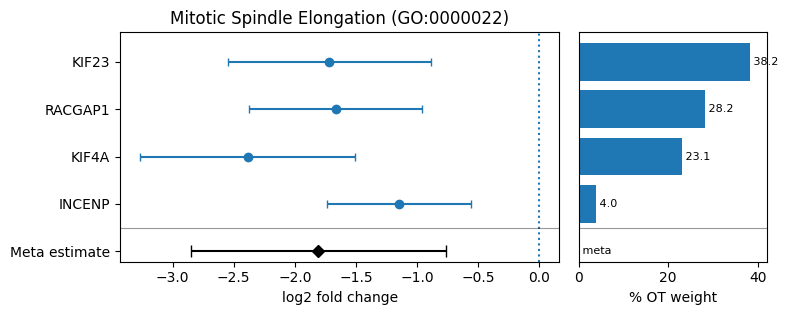

In [810]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

genes = go_terms_to_check[term]

example = table[table.symbol.isin(genes)].copy()

weight_map = OT_mat[term]
example["term_weights"] = example["symbol"].map(weight_map)

example["uci"] = example["log2FoldChange"] + 1.96 * example["lfcSE"]
example["lci"] = example["log2FoldChange"] - 1.96 * example["lfcSE"]

example["term_weight_rel"] = example["term_weights"] / example["term_weights"].max()
example["term_weight_pct"] = 100 * example["term_weights"] / example["term_weights"].sum()

example["term_pct_contribution"] = (
    example["term_weights"] / example["term_weights"].sum()
)

example = example.sort_values("term_pct_contribution", ascending=False)

if example \
    .sort_values("term_pct_contribution", ascending=False) \
    .assign(cum_pct=lambda x: x["term_pct_contribution"].cumsum()) \
    .loc[lambda x: x["cum_pct"].lt(0.99)] \
    .copy().shape[0] > 3:

    example = (
        example
        .sort_values("term_pct_contribution", ascending=False)
        .assign(cum_pct=lambda x: x["term_pct_contribution"].cumsum())
        .loc[lambda x: x["cum_pct"].lt(0.95)]
        .copy()
    )


# Add meta estimate row
meta = result_table.loc[term]

meta_row = pd.DataFrame({
    "symbol": ["Meta estimate"],
    "log2FoldChange": [meta["beta"]],
    "lci": [meta["beta"] - 1.96 * meta["variance"]],
    "uci": [meta["beta"] + 1.96 * meta["variance"]],
    "term_weights": [np.nan],
    "term_weight_rel": [np.nan],
    "term_weight_pct": [np.nan],
    "term_pct_contribution": [np.nan],
    "cum_pct": [np.nan],
    "is_meta": [True],
})

example["is_meta"] = False

example = pd.concat(
    [example, meta_row],
    ignore_index=True,
)

y = np.arange(len(example))

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(8, 0.35 * len(example) + 1.5),
    sharey=True,
    gridspec_kw={"width_ratios": [3.5, 1.5]}
)

is_meta = example["is_meta"].to_numpy()
not_meta = ~is_meta

# Forest plot: individual genes
ax1.errorbar(
    example.loc[not_meta, "log2FoldChange"],
    y[not_meta],
    xerr=[
        example.loc[not_meta, "log2FoldChange"] - example.loc[not_meta, "lci"],
        example.loc[not_meta, "uci"] - example.loc[not_meta, "log2FoldChange"],
    ],
    fmt="o",
    capsize=3,
)

# Forest plot: meta estimate in black
ax1.errorbar(
    example.loc[is_meta, "log2FoldChange"],
    y[is_meta],
    xerr=[
        example.loc[is_meta, "log2FoldChange"] - example.loc[is_meta, "lci"],
        example.loc[is_meta, "uci"] - example.loc[is_meta, "log2FoldChange"],
    ],
    fmt="D",
    capsize=4,
    color="black",
    ecolor="black",
    markersize=6,
    label="Meta estimate",
)

ax1.axvline(0, linestyle=":")
ax1.set_yticks(y)
ax1.set_yticklabels(example["symbol"])
ax1.invert_yaxis()
ax1.set_xlabel("log2 fold change")
ax1.set_title(term)

# Optional separator above meta estimate
meta_y = y[is_meta][0]
ax1.axhline(meta_y - 0.5, color="black", linewidth=0.8, alpha=0.4)
ax2.axhline(meta_y - 0.5, color="black", linewidth=0.8, alpha=0.4)

# Right-side weight bars, genes only
bar_values = example["term_weight_pct"].fillna(0)

ax2.barh(
    y[not_meta],
    bar_values.loc[not_meta],
)

ax2.set_xlabel("% OT weight")
ax2.set_xlim(0, bar_values.max() * 1.1 if bar_values.max() > 0 else 1)

# Numeric labels, genes only
for yi, val, meta_flag in zip(y, bar_values, is_meta):
    if not meta_flag:
        ax2.text(
            val,
            yi,
            f" {val:.1f}",
            va="center",
            ha="left",
            fontsize=8,
        )

# Optional label for meta row on bar side
ax2.text(
    0,
    meta_y,
    " meta",
    va="center",
    ha="left",
    fontsize=8,
    color="black",
)

# Clean up
ax2.tick_params(axis="y", left=False, labelleft=False)

plt.tight_layout()
plt.show()

In [ ]:
# Reweighting

In [ ]:
class IterativeProportionalFitting:

    def get_balanced_matrix(
        self, 
        assignment_matrix: pd.DataFrame, 
        row_marginals: pd.Series, 
        column_marginals: pd.Series
    ) -> pd.DataFrame:

        joint_index = self.clean_inputs(assignment_matrix, row_marginals, column_marginals)

        assignment_matrix = assignment_matrix.loc[joint_index]
        row_marginals = row_marginals.loc[joint_index]
        column_marginals = column_marginals.loc[assignment_matrix.columns]

        A = assignment_matrix.values
        u = row_marginals.values
        v = column_marginals.values

        while delta > 1e-6:
            A_u1 = ((A * u) / A.sum(axis=0))
            A_u2 = ((A_u1.T * v) / A_u1.sum(axis=1)).T

            delta = np.pow((A - A_u2), 2).sum() / np.pow(A, 2).sum()

            A = A_u2

        pd.DataFrame(
            A,
            index=go_terms_A.index,
            columns=go_terms_A.columns
        )

    def clean_inputs(
        self, 
        assignment_matrix: pd.DataFrame, 
        row_marginals: pd.Series, 
        column_marginals: pd.Series
    ):
        return assignment_matrix.index.intersection(row_marginals.index)

In [ ]:
# Feature Selection


Index(['AAK1', 'AARS1', 'AARS2', 'AASDHPPT', 'ABAT', 'ABCA13', 'ABCA2',
       'ABCA3', 'ABCA5', 'ABCA6',
       ...
       'ZSWIM7', 'ZSWIM8', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDB', 'ZXDC', 'ZYG11B',
       'ZYX', 'ZZZ3'],
      dtype='str', length=8746)

In [814]:
A = go_term_A.values

u = (1 / go_term_A.gt(0).sum(axis=0).apply(np.sqrt)).values
v = subset.set_index("symbol").loc[go_term_A.index, "weights"].values



In [ ]:
pd.DataFrame(
    A,
    index=go_term_A.index,
    columns=go_term_A.columns
)

AAK1        0.000091
AARS1       0.000142
AARS2       0.000020
AASDHPPT    0.000038
ABAT        0.000020
              ...   
ZXDB        0.000011
ZXDC        0.000013
ZYG11B      0.000061
ZYX         0.000463
ZZZ3        0.000047
Length: 8746, dtype: float64